# **Imports**

In [1]:
!pip install iterative-stratification

In [2]:
!pip install nlpaug transformers torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 10.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import nlpaug.augmenter.word as naw
import random
import nltk
import re
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
from sklearn.metrics import f1_score
import time


In [4]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# **Dataset Preprocessing**

In [9]:
data = pd.read_csv("train.csv")

In [10]:
print("Dataset Info:")
print(data.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB
None


In [11]:
print("\nDataset Description:")
print(data.describe())


Dataset Description:
               toxic   severe_toxic        obscene         threat  \
count  159571.000000  159571.000000  159571.000000  159571.000000   
mean        0.095844       0.009996       0.052948       0.002996   
std         0.294379       0.099477       0.223931       0.054650   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       0.000000   
50%         0.000000       0.000000       0.000000       0.000000   
75%         0.000000       0.000000       0.000000       0.000000   
max         1.000000       1.000000       1.000000       1.000000   

              insult  identity_hate  
count  159571.000000  159571.000000  
mean        0.049364       0.008805  
std         0.216627       0.093420  
min         0.000000       0.000000  
25%         0.000000       0.000000  
50%         0.000000       0.000000  
75%         0.000000       0.000000  
max         1.000000       1.000000  


In [12]:
data.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [13]:
print("\nMissing Values:")
data.isnull().sum()


Missing Values:


,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [14]:
# Count the number of duplicate rows
duplicate_count = data.duplicated().sum()
print(f"Number of duplicate rows before removal: {duplicate_count}")

Number of duplicate rows before removal: 0


# **Data Spliting**

In [15]:



X = data[["comment_text"]]
y = data[["toxic","severe_toxic","obscene","threat","insult","identity_hate"]]

# =====================================================
# First Split: 70% Train / 30% Temp
# =====================================================

msss1 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(msss1.split(X, y))

train_df = data.iloc[train_idx].reset_index(drop=True)
temp_df  = data.iloc[temp_idx].reset_index(drop=True)

# =====================================================
# Second Split: 15% Validation / 15% Test
# =====================================================

X_temp = temp_df[["comment_text"]]

y_temp = temp_df[[
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]]

msss2 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(msss2.split(X_temp, y_temp))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# =====================================================
# Check Sizes
# =====================================================

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

total = len(data)

print(f"Train: {len(train_df)/total:.2%}")
print(f"Validation: {len(val_df)/total:.2%}")
print(f"Test: {len(test_df)/total:.2%}")

Train: (111699, 8)
Validation: (23936, 8)
Test: (23936, 8)
Train: 70.00%
Validation: 15.00%
Test: 15.00%


# **Data Augmentation**


In [16]:
print("Training samples:", len(train_df))

print("\nLabel counts:")
print(train_df[[
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]].sum())

rare_rows = train_df[
    (train_df["severe_toxic"] == 1) |
    (train_df["threat"] == 1) |
    (train_df["identity_hate"] == 1)
]

print("\nUnique rows to augment:", len(rare_rows))

Training samples: 111699

Label counts:
toxic            10706
severe_toxic      1116
obscene           5914
threat             335
insult            5514
identity_hate      983
dtype: int64

Unique rows to augment: 2086


In [17]:
aug_sub = naw.SynonymAug(aug_src='wordnet', aug_p=0.15)
aug_swap = naw.RandomWordAug(action="swap", aug_p=0.1)

In [18]:
# current counts -> target counts (adjust to taste)
targets = {
    'threat': 8000,
    'identity_hate': 8000,
    'severe_toxic': 8000,
}

In [19]:
def augment_row(text, n_versions=1):
    outputs = []
    for i in range(n_versions):
        try:
            if i % 2 == 0:
                new_text = aug_sub.augment(text)
            else:
                new_text = aug_swap.augment(text)
            new_text = new_text[0] if isinstance(new_text, list) else new_text
            outputs.append(new_text)
        except Exception as e:
            print(f"Skipped a row due to: {e}")
    return outputs

In [20]:
augmented_rows = []

for label, target_count in targets.items():
    subset = train_df[train_df[label] == 1]
    current_count = len(subset)
    needed = target_count - current_count

    if needed <= 0:
        print(f"{label}: already at/above target, skipping")
        continue

    print(f"{label}: {current_count} -> {target_count} (generating {needed} new rows)")

    # how many augmented versions per original row (rounded up)
    per_row = max(1, needed // current_count + 1)

    count_generated = 0
    for _, row in subset.iterrows():
        if count_generated >= needed:
            break
        versions = augment_row(row['comment_text'], n_versions=per_row)
        for v in versions:
            if count_generated >= needed:
                break
            new_row = row.copy()
            new_row['comment_text'] = v
            augmented_rows.append(new_row)
            count_generated += 1

aug_df = pd.DataFrame(augmented_rows)
print(f"\nTotal augmented rows generated: {len(aug_df)}")

threat: 335 -> 8000 (generating 7665 new rows)
identity_hate: 983 -> 8000 (generating 7017 new rows)
severe_toxic: 1116 -> 8000 (generating 6884 new rows)

Total augmented rows generated: 21566


In [21]:
train_augmented = pd.concat([train_df, aug_df], ignore_index=True)
train_augmented = train_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

print("New label counts:")

print(
    train_augmented[
        [
            "toxic",
            "severe_toxic",
            "obscene",
            "threat",
            "insult",
            "identity_hate"
        ]
    ].sum()
)


New label counts:
toxic            31314
severe_toxic     11446
obscene          22317
threat            8951
insult           21957
identity_hate    10824
dtype: int64


# **Tokenizer + Vocabulary**


In [22]:

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # remove URLs
    text = re.sub(r"[^a-z0-9\s']", " ", text)              # keep letters/numbers/apostrophes
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# Build vocabulary from TRAINING data only (never fit on val/test)
def build_vocab(texts, min_freq=2, max_vocab_size=30000):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenize(text))

    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.most_common(max_vocab_size):
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train_augmented['comment_text'])
print(f"Vocab size: {len(vocab)}")

Vocab size: 30002


In [23]:
MAX_LEN = 150 # adjust based on your comment length distribution

def encode_text(text, vocab, max_len=MAX_LEN):
    tokens = simple_tokenize(text)
    ids = [vocab.get(tok, vocab['<UNK>']) for tok in tokens[:max_len]]
    if len(ids) == 0:
        ids = [vocab['<UNK>']]
    return ids

# quick check on comment length distribution to justify MAX_LEN
lengths = train_augmented['comment_text'].apply(lambda x: len(simple_tokenize(x)))
print(lengths.describe())
print(f"95th percentile length: {lengths.quantile(0.95)}")

count    133265.000000
mean         67.094518
std         110.942686
min           0.000000
25%          15.000000
50%          33.000000
75%          71.000000
max        1407.000000
Name: comment_text, dtype: float64
95th percentile length: 231.0


In [24]:
class ToxicDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN):
        self.texts = df['comment_text'].values
        self.labels = df[label_cols].values.astype('float32')
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts[idx], self.vocab, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx])

def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences])
    padded = pad_sequence(sequences, batch_first=True, padding_value=vocab['<PAD>'])
    labels = torch.stack(labels)
    return padded, labels, lengths

In [25]:
BATCH_SIZE = 64

# Build vocab from AUGMENTED TRAINING data only
vocab = build_vocab(train_augmented['comment_text'])
print(f"Vocab size: {len(vocab)}")

train_dataset = ToxicDataset(train_augmented, vocab, max_len=150)
val_dataset   = ToxicDataset(val_df, vocab, max_len=150)
test_dataset  = ToxicDataset(test_df, vocab, max_len=150)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Vocab size: 30002
Train batches: 2083
Val batches: 374
Test batches: 374


# **Training Different LSTM Architectures**

---




In [26]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=2, bidirectional=True, dropout=0.3,
                 num_classes=6, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        mult = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * mult * 2, num_classes)  # *2 for mean+max

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        lengths = lengths.clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.rnn(packed)   # LSTM returns (h_n, c_n) here but we ignore it, same as before
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        mask = (outputs.abs().sum(dim=2) != 0).unsqueeze(2).float()
        mean_pool = (outputs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        max_pool = outputs.masked_fill(mask == 0, -1e9).max(dim=1)[0]
        combined = torch.cat([mean_pool, max_pool], dim=1)
        return self.fc(self.dropout(combined))

In [27]:
lstm_configs = {
    "Simple_LSTM":           dict(num_layers=1, bidirectional=False, dropout=0.0),
    "Stacked_LSTM":          dict(num_layers=2, bidirectional=False, dropout=0.0),
    "Deep_LSTM":             dict(num_layers=3, bidirectional=False, dropout=0.0),
    "Bidirectional_LSTM":    dict(num_layers=1, bidirectional=True,  dropout=0.0),
    "Stacked_BiLSTM":        dict(num_layers=2, bidirectional=True,  dropout=0.0),
    "LSTM_Dropout":          dict(num_layers=1, bidirectional=False, dropout=0.3),
    "BiLSTM_Dropout":        dict(num_layers=1, bidirectional=True,  dropout=0.3),
}

In [28]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y, lengths in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # helps vanilla RNN stability
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    for x, y, lengths in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x, lengths)
        loss = criterion(logits, y)
        total_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)

    return total_loss / len(loader), f1_macro, f1_micro, all_preds, all_labels

In [29]:
def run_experiment(model_class, config_name, config, vocab_size,
                    train_loader, val_loader, pos_weight=None, epochs=8, lr=1e-3):
    print(f"\n{'='*50}\nTraining: {config_name}\n{'='*50}")

    model = model_class(
        vocab_size=vocab_size, embed_dim=128, hidden_dim=128,
        num_classes=6, **config
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    history = {"train_loss": [], "val_loss": [], "val_f1_macro": [], "val_f1_micro": []}
    best_f1_macro = 0
    best_state = None

    for epoch in range(epochs):
        start = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, f1_macro, f1_micro, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1_macro"].append(f1_macro)
        history["val_f1_micro"].append(f1_micro)
        if f1_macro > best_f1_macro:
            best_f1_macro = f1_macro
            best_state = model.state_dict()
        elapsed = time.time() - start
        print(f"Epoch {epoch+1}/{epochs} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_F1_macro={f1_macro:.4f} | "
              f"val_F1_micro={f1_micro:.4f} | {elapsed:.1f}s")

    model.load_state_dict(best_state)
    return model, history, best_f1_macro

In [32]:
vocab_size =  30002
lstm_results = {}
lstm_models = {}
pos_counts = train_augmented[label_cols].sum().values
neg_counts = len(train_augmented) - pos_counts
pos_weight = torch.tensor(np.clip(neg_counts / pos_counts, 1, 10), dtype=torch.float32).to(device)

for name, config in lstm_configs.items():
    model, history, best_f1 = run_experiment(
        LSTMClassifier, name, config, vocab_size,
        train_loader, val_loader, pos_weight=pos_weight, epochs=8, lr=1e-3
    )
    lstm_results[name] = {"history": history, "best_val_f1_macro": best_f1}
    lstm_models[name] = model

best_lstm_name = max(lstm_results, key=lambda k: lstm_results[k]["best_val_f1_macro"])
print(f"\n🏆 Best LSTM architecture: {best_lstm_name} (val F1 macro = {lstm_results[best_lstm_name]['best_val_f1_macro']:.4f})")


Training: Simple_LSTM
Epoch 1/8 | train_loss=0.3234 | val_loss=0.1512 | val_F1_macro=0.5320 | val_F1_micro=0.6668 | 52.0s
Epoch 2/8 | train_loss=0.1560 | val_loss=0.1391 | val_F1_macro=0.5756 | val_F1_micro=0.6939 | 51.6s
Epoch 3/8 | train_loss=0.1127 | val_loss=0.1457 | val_F1_macro=0.5977 | val_F1_micro=0.7267 | 51.0s
Epoch 4/8 | train_loss=0.0921 | val_loss=0.1465 | val_F1_macro=0.5810 | val_F1_micro=0.7149 | 50.5s
Epoch 5/8 | train_loss=0.0787 | val_loss=0.1572 | val_F1_macro=0.6009 | val_F1_micro=0.7275 | 50.4s
Epoch 6/8 | train_loss=0.0683 | val_loss=0.1696 | val_F1_macro=0.5914 | val_F1_micro=0.7284 | 54.7s
Epoch 7/8 | train_loss=0.0611 | val_loss=0.1697 | val_F1_macro=0.5854 | val_F1_micro=0.7187 | 52.8s
Epoch 8/8 | train_loss=0.0533 | val_loss=0.1791 | val_F1_macro=0.5821 | val_F1_micro=0.7183 | 52.7s

Training: Stacked_LSTM
Epoch 1/8 | train_loss=0.3131 | val_loss=0.1493 | val_F1_macro=0.5641 | val_F1_micro=0.6846 | 67.5s
Epoch 2/8 | train_loss=0.1496 | val_loss=0.1394 | val

In [34]:
from sklearn.metrics import f1_score

@torch.no_grad()
def get_final_metrics(model, loader, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    for x, y, lengths in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x, lengths)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return f1_macro, f1_micro, f1_weighted, all_preds, all_labels

In [36]:
lstm_final_metrics = {}
for name, model in lstm_models.items():
    f1_macro, f1_micro, f1_weighted, preds, labels = get_final_metrics(model, val_loader)
    lstm_final_metrics[name] = {
        "f1_macro": f1_macro, "f1_micro": f1_micro, "f1_weighted": f1_weighted,
        "preds": preds, "labels": labels
    }
    print(f"{name}: F1_macro={f1_macro:.4f}, F1_micro={f1_micro:.4f}, F1_weighted={f1_weighted:.4f}")

Simple_LSTM: F1_macro=0.5821, F1_micro=0.7183, F1_weighted=0.7274
Stacked_LSTM: F1_macro=0.5831, F1_micro=0.7114, F1_weighted=0.7165
Deep_LSTM: F1_macro=0.6054, F1_micro=0.7358, F1_weighted=0.7417
Bidirectional_LSTM: F1_macro=0.6116, F1_micro=0.7402, F1_weighted=0.7439
Stacked_BiLSTM: F1_macro=0.5990, F1_micro=0.7302, F1_weighted=0.7393
LSTM_Dropout: F1_macro=0.5904, F1_micro=0.7282, F1_weighted=0.7415
BiLSTM_Dropout: F1_macro=0.6044, F1_micro=0.7385, F1_weighted=0.7411


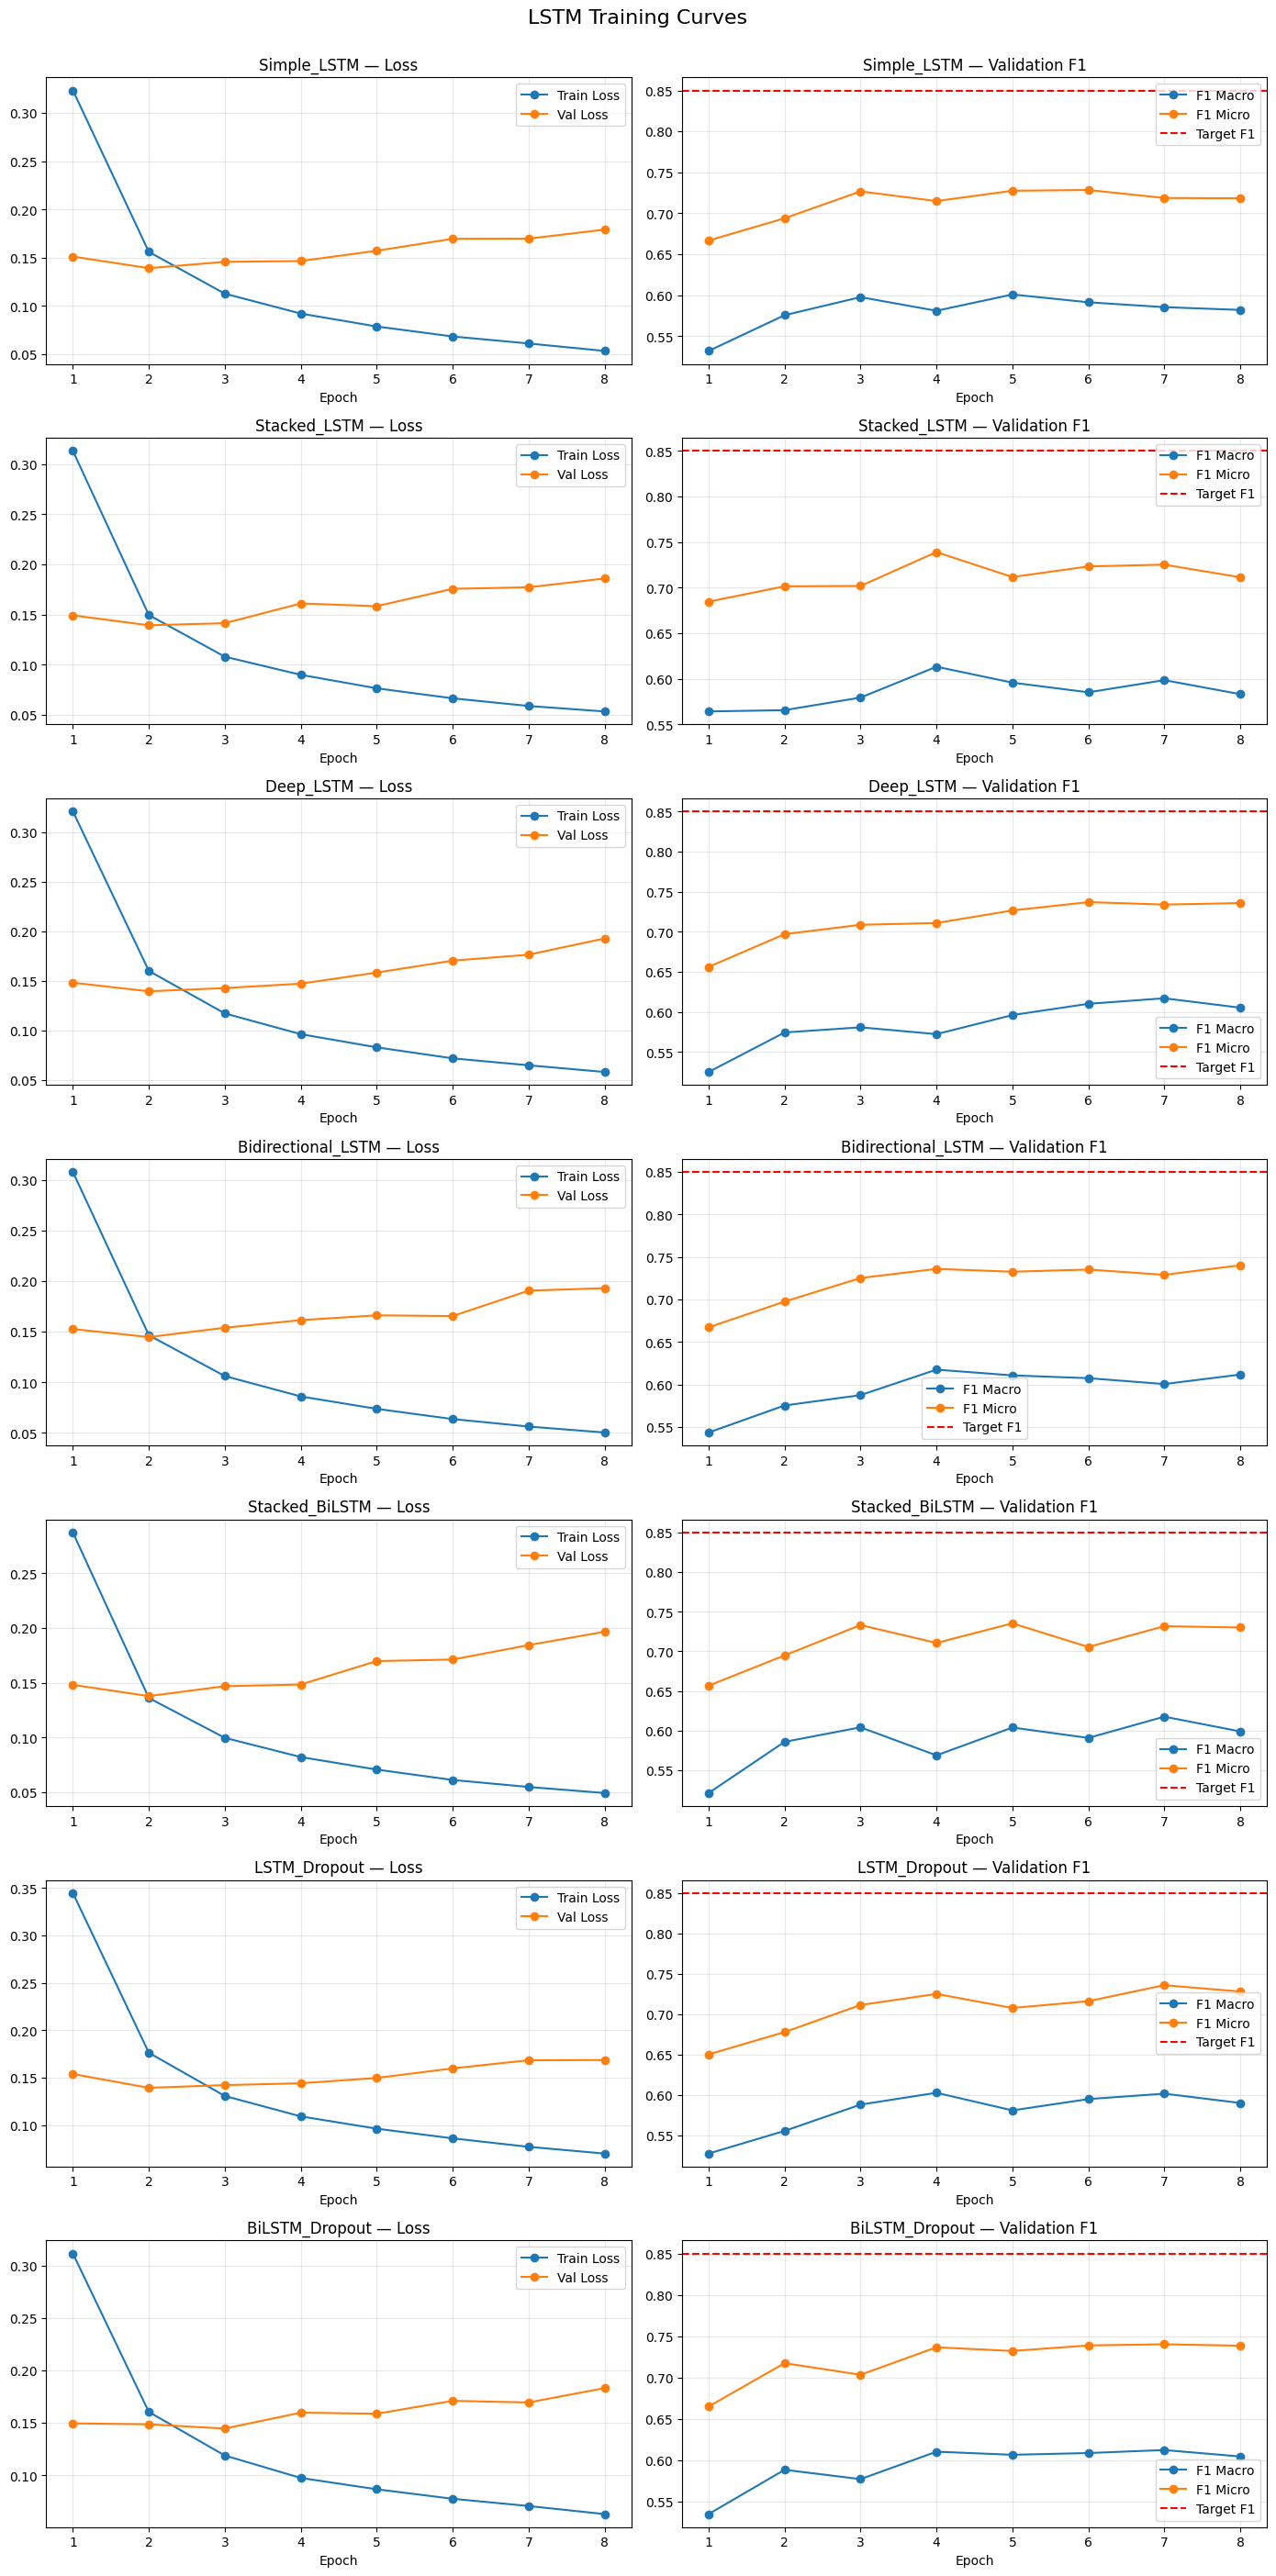

In [37]:
def plot_training_curves(results, family_name, target_f1):
    n = len(results)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4*n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for i, (name, res) in enumerate(results.items()):
        h = res["history"]
        epochs_range = range(1, len(h["train_loss"]) + 1)

        axes[i, 0].plot(epochs_range, h["train_loss"], label="Train Loss", marker='o')
        axes[i, 0].plot(epochs_range, h["val_loss"], label="Val Loss", marker='o')
        axes[i, 0].set_title(f"{name} — Loss")
        axes[i, 0].set_xlabel("Epoch")
        axes[i, 0].legend()
        axes[i, 0].grid(alpha=0.3)

        axes[i, 1].plot(epochs_range, h["val_f1_macro"], label="F1 Macro", marker='o')
        axes[i, 1].plot(epochs_range, h["val_f1_micro"], label="F1 Micro", marker='o')
        axes[i, 1].axhline(y=target_f1, color='red', linestyle='--', label='Target F1')
        axes[i, 1].set_title(f"{name} — Validation F1")
        axes[i, 1].set_xlabel("Epoch")
        axes[i, 1].legend()
        axes[i, 1].grid(alpha=0.3)

    plt.suptitle(f"{family_name} Training Curves", fontsize=16, y=1.001)
    plt.tight_layout()
    plt.savefig(f"{family_name}_training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()


plot_training_curves(lstm_results, "LSTM", target_f1=0.85)

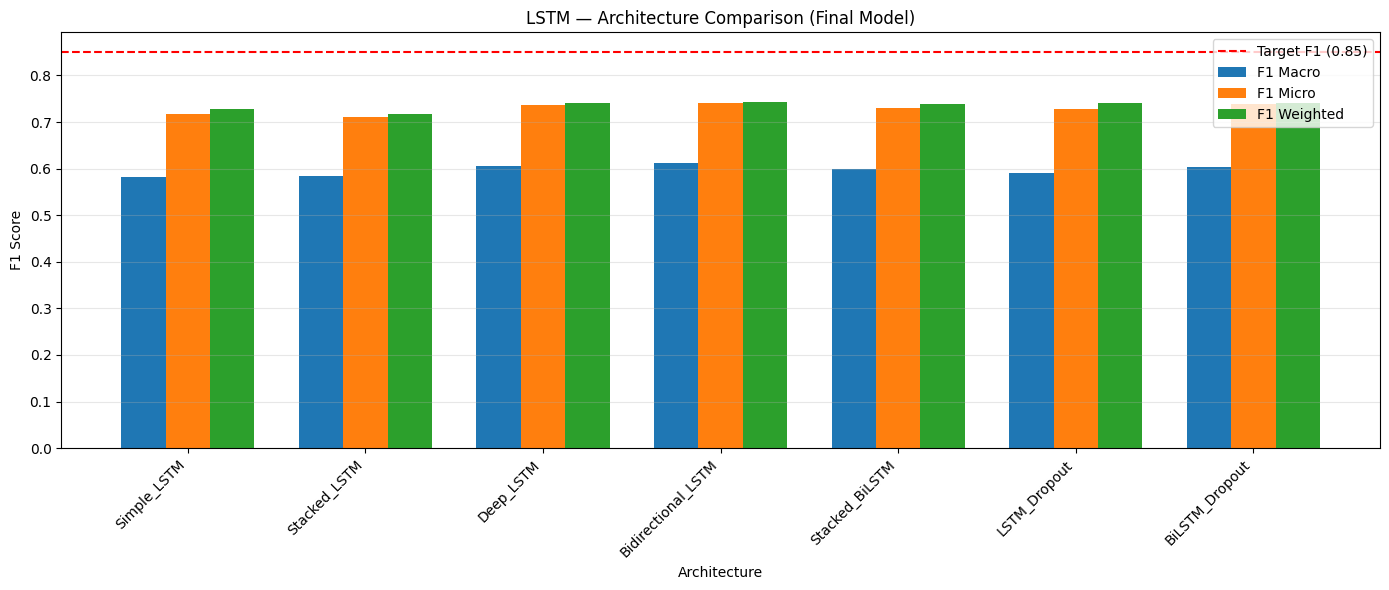

In [40]:


def plot_architecture_comparison(final_metrics, family_name, target_f1):
    names = list(final_metrics.keys())
    macro_scores = [final_metrics[n]["f1_macro"] for n in names]
    micro_scores = [final_metrics[n]["f1_micro"] for n in names]
    weighted_scores = [final_metrics[n]["f1_weighted"] for n in names]

    x = np.arange(len(names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - width, macro_scores, width, label='F1 Macro')
    ax.bar(x, micro_scores, width, label='F1 Micro')
    ax.bar(x + width, weighted_scores, width, label='F1 Weighted')
    ax.axhline(y=target_f1, color='red', linestyle='--', label=f'Target F1 ({target_f1})')

    ax.set_xlabel('Architecture')
    ax.set_ylabel('F1 Score')
    ax.set_title(f'{family_name} — Architecture Comparison (Final Model)')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f"{family_name}_architecture_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()


plot_architecture_comparison(lstm_final_metrics, "LSTM", target_f1=0.85)

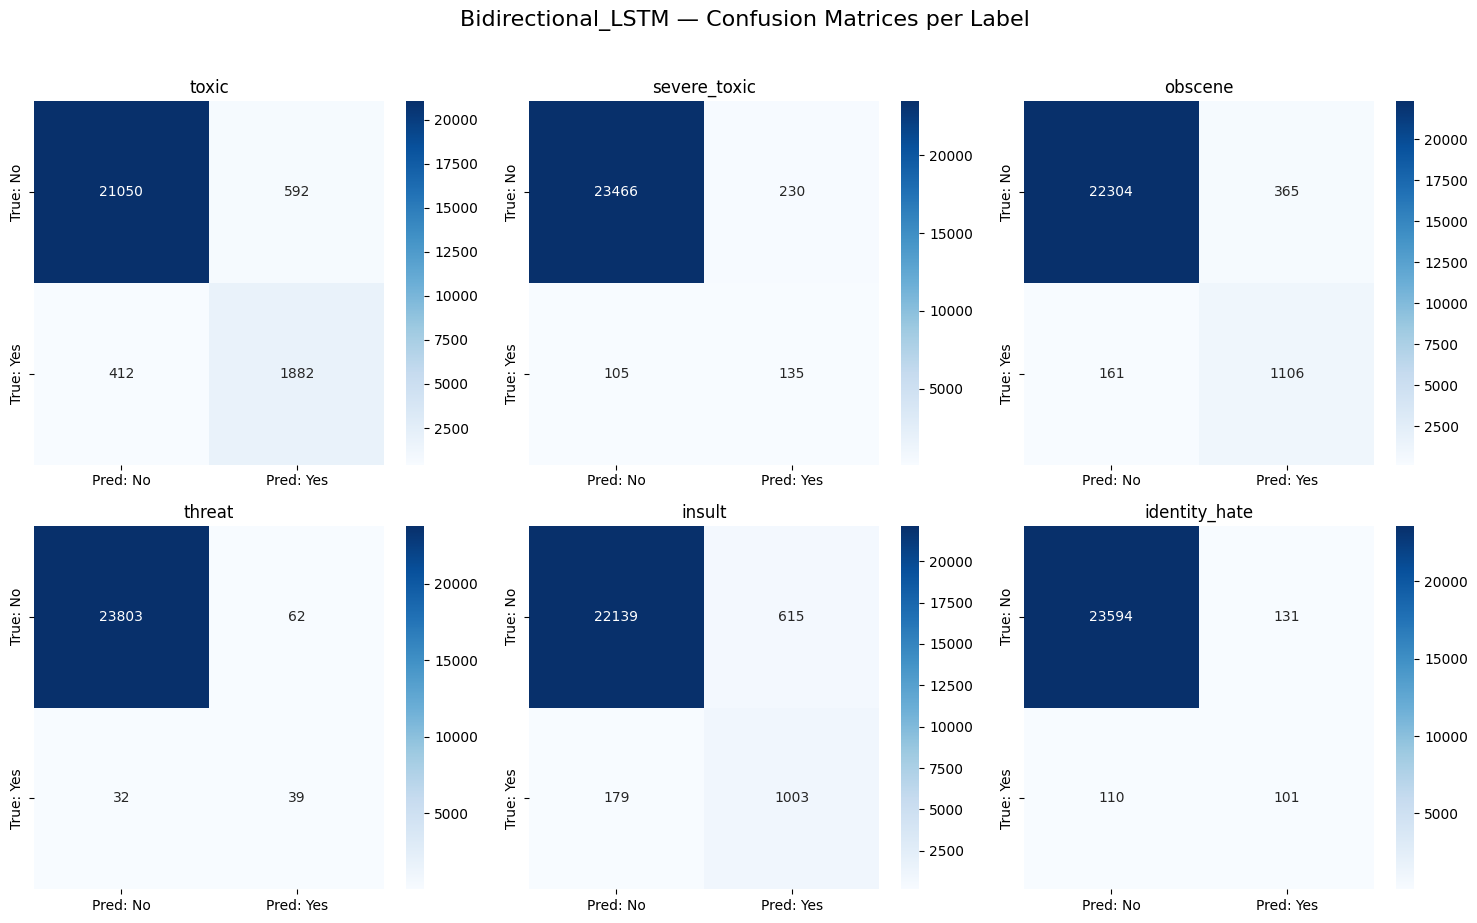

In [38]:
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns

def plot_confusion_matrices(preds, labels, label_names, model_name):
    cms = multilabel_confusion_matrix(labels, preds)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    for i, (cm, label_name) in enumerate(zip(cms, label_names)):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Pred: No', 'Pred: Yes'],
                    yticklabels=['True: No', 'True: Yes'])
        axes[i].set_title(f'{label_name}')

    plt.suptitle(f'{model_name} — Confusion Matrices per Label', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrices.png", dpi=150, bbox_inches='tight')
    plt.show()

best_lstm_name = max(lstm_final_metrics, key=lambda k: lstm_final_metrics[k]["f1_macro"])



plot_confusion_matrices(lstm_final_metrics[best_lstm_name]["preds"],
                         lstm_final_metrics[best_lstm_name]["labels"],
                         label_cols, best_lstm_name)

In [39]:


def build_summary_table(final_metrics, family_name):
    rows = []
    for name, m in final_metrics.items():
        rows.append({
            "Architecture": name,
            "F1 Macro": m["f1_macro"],
            "F1 Micro": m["f1_micro"],
            "F1 Weighted": m["f1_weighted"],
        })
    df = pd.DataFrame(rows).sort_values("F1 Macro", ascending=False)
    print(f"\n{family_name} Summary:")
    print(df.to_string(index=False))
    return df


lstm_summary = build_summary_table(lstm_final_metrics, "LSTM")


LSTM Summary:
      Architecture  F1 Macro  F1 Micro  F1 Weighted
Bidirectional_LSTM  0.611583  0.740239     0.743947
         Deep_LSTM  0.605387  0.735766     0.741702
    BiLSTM_Dropout  0.604351  0.738454     0.741128
    Stacked_BiLSTM  0.598998  0.730161     0.739267
      LSTM_Dropout  0.590410  0.728202     0.741486
      Stacked_LSTM  0.583102  0.711401     0.716535
       Simple_LSTM  0.582052  0.718259     0.727364
